# Testing the Ammonyte Package for Detecting Tipping Points

## Overview
This notebook demonstrates the application of the **ammonyte** package
for detecting abrupt climate transitions and tipping points in
paleoclimate time series data. The analysis focuses on identifying rapid
shifts in Earth's climate system that may indicate critical transitions
between different climate states.

## Scientific Background
**Tipping points** represent **critical transition events** in the
climate system where the system rapidly shifts from one stable state to
another. These abrupt transitions are fundamental to understanding:
- Past climate variability and stability
- Mechanisms driving abrupt climate change
- Early warning signals for future climate shifts

## Methodology
The primary detection method employed is the **augmented 
Kolmogorov-Smirnov (KS) test**, a statistical approach specifically
designed for identifying abrupt transitions.

## Implementation
The workflow and parameter settings are based on the methodology
described in:

**Reference**: [Bagniewski, W., et al. (2021). "Automatic detection of 
abrupt transitions in paleoclimate records." *Chaos* 31, 
113129.](https://doi.org/10.1063/5.0062543)

## Dataset
Analysis will be performed on the **NGRIP (North Greenland Ice Core 
Project)** dataset, which provides high-resolution $\delta^{18}O$ isotope
measurements spanning the last glacial period—ideal for studying
Dansgaard-Oeschger events and other rapid climate transitions.

## Expected Outcomes
- Identification and quantification of abrupt climate transitions
- Statistical characterization of transition timing and magnitude
- Visualization of detected tipping points in the context of paleoclimate
variability

## Import Required Libraries

Import essential packages for paleoclimate data analysis and tipping point detection:
- **Scientific computing**: NumPy, Pandas
- **Climate analysis**: Ammonyte package with Series class and KS_test module

In [1]:
import numpy as np
import pandas as pd
import ammonyte as amt
from ammonyte.core.series import Series
from ammonyte.utils.ks import KS_test

## Load the NGRIP Dataset for Tipping Point Analysis

### Dataset Overview
The **North Greenland Ice Core Project (NGRIP)** dataset contains
high-resolution paleoclimate proxy data from Greenland ice cores. This
dataset is particularly valuable for studying abrupt climate transitions
and tipping points in the Earth's climate system.

**Key Dataset Features:**
- **Proxy Variable**: $\delta^{18}O$ isotope measurements
- **Units**: per mill (‰) 
- **Time Scale**: Thousands of years before present (kyr b2k)

### Technical Implementation
The dataset is stored in **pyleoclim-compatible CSV format** with
metadata headers delimited by `###` markers. Ammonyte leverages
pyleoclim's robust CSV parsing capabilities while extending functionality
for tipping point 

**CSV Structure:**
- Metadata section: Contains time/value names, units, labels
- Data section: Two-column format (time, proxy value)
- Format: Compatible with both ammonyte and pyleoclim ecosystems




In [2]:
# Load NGRIP dataset using the proper ammonyte data path
ngrip = amt.Series.from_csv('../ammonyte/data/NGRIP.csv')

# Display basic metadata about the dataset
print(f"Loaded NGRIP dataset: {ngrip.label}")
print(f"Time range: {ngrip.time.min():.2f} - {ngrip.time.max():.2f} {ngrip.time_unit}")
print(f"Number of data points: {len(ngrip.time)}")
print(f"Value range: {ngrip.value.min():.2f} - {ngrip.value.max():.2f} {ngrip.value_unit}")

# Show the object
ngrip

Time axis values sorted in ascending order
Time axis values sorted in ascending order
Loaded NGRIP dataset: NGRIP Ice Core Data
Time range: 0.05 - 122.27 kyr b2k
Number of data points: 6112
Value range: -46.50 - -32.11 per mill
{'label': 'NGRIP Ice Core Data'}


None
Age [kyr b2k]
0.05     -35.11
0.07     -34.65
0.09     -34.53
0.11     -35.29
0.13     -35.02
          ...  
122.19   -32.85
122.21   -32.66
122.23   -32.66
122.25   -32.51
122.27   -32.56
Name: δ18O [%] [per mill], Length: 6112, dtype: float64

The information of dataset

Extracting time and value data and plotting the dataset 

## Dataset Metadata Summary

Display key metadata information from the loaded NGRIP time series to understand the dataset characteristics.

In [3]:
print("=== NGRIP DATASET INFO ===")
print(f"Original NGRIP series label: {ngrip.label}")
print(f"Value name: {ngrip.value_name}")
print(f"Value unit: {ngrip.value_unit}")
print(f"Time name: {ngrip.time_name}")
print(f"Time unit: {ngrip.time_unit}")


=== NGRIP DATASET INFO ===
Original NGRIP series label: NGRIP Ice Core Data
Value name: δ18O [%]
Value unit: per mill
Time name: Age
Time unit: kyr b2k


### NGRIP δ¹⁸O Record Visualization
The plot below shows the complete NGRIP ice core record, where:
- **X-axis**: Time in thousands of years before present (kyr b2k)
- **Y-axis**: $\delta^{18}O$ isotope values in per mille (‰)
- **Interpretation**: More negative values typically indicate colder
conditions

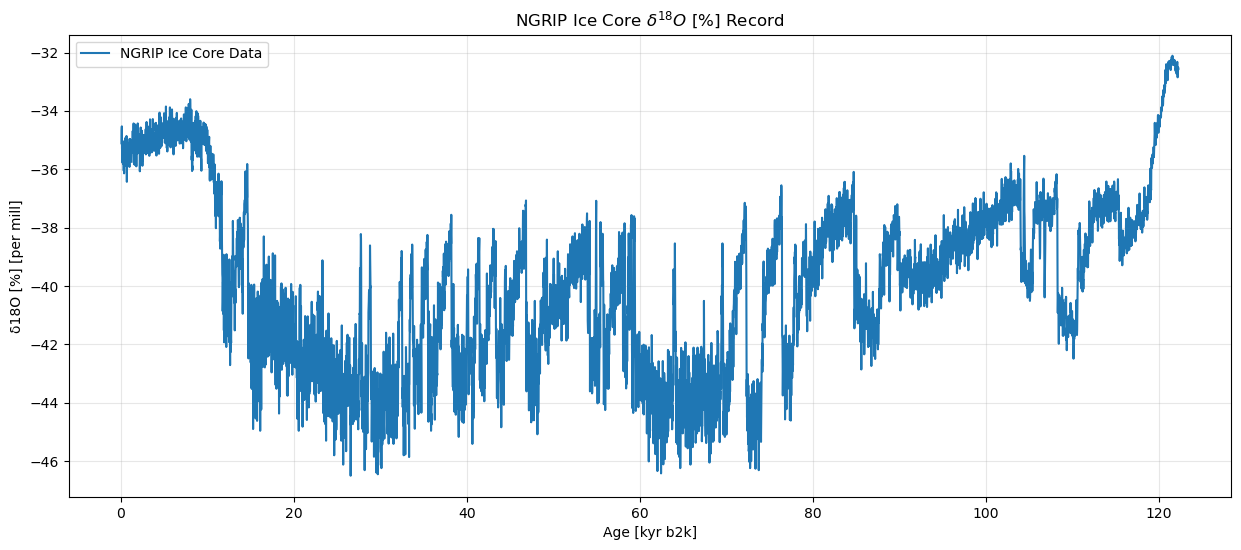

In [4]:
# The NGRIP series is already loaded with proper metadata
#plot the time series to visualize the data
fig, ax = ngrip.plot(figsize=(15, 6))
ax.set_title('NGRIP Ice Core $\delta^{18}O\ [\%]$ Record')
ax.grid(True, alpha=0.3)

## Applying the Augmented Kolmogorov-Smirnov Test for Transition
Detection

### Algorithm Overview
The augmented KS test systematically scans the time series using sliding
windows of varying sizes to identify statistically significant abrupt
transitions. The algorithm compares statistical distributions before and
after potential transition points.

### KS Test Parameters (Optimized for NGRIP Dataset)
These parameters are based on **Bagniewski et al. 2021** and optimized
for NGRIP ice core data characteristics:

**Window Configuration:**
- `w_min = 0.12`: Minimum window size (120 years) - captures short-term
transitions
- `w_max = 2.5`: Maximum window size (2,500 years) - captures longer-term
shifts
- `n_w = 15`: Number of logarithmically-spaced window sizes tested

**Detection Thresholds:**
- `d_c = 0.77`: KS statistic threshold - higher values = more stringent
detection
- `n_c = 3`: Minimum samples per window half - ensures statistical robustness
- `s_c = 2`: Standard deviation ratio cutoff - filters noise-driven
changes
- `x_c = 0.8`: Minimum proxy value change (‰) - physical significance threshold

In [5]:
# Apply KS test using the high-level ammonyte interface
# Parameters from Bagniewski et al. 2021 for NGRIP dataset
transitions = ngrip.kstest(w_min=0.12, w_max=2.5, n_w=15, d_c=0.77, n_c=3, s_c=2, x_c=0.8)

print(f"Detected {len(transitions.jump_times)} transitions")
print(transitions)

Detected 104 transitions
Deterministic Transition Detection Results - NGRIP Ice Core Data
+----------+---------------------+----------------+------------------+---------------------+
| Method   |   Total Transitions |   Upward Jumps |   Downward Jumps | Series Label        |
+==========+=====================+================+==================+=====================+
| KS test  |                 104 |             49 |               55 | NGRIP Ice Core Data |
+----------+---------------------+----------------+------------------+---------------------+

Transition Details:
  1. Time: 8.14 kyr b2k, Direction: Upward, d_statistics: 0.4080, p_values: < 1e-8
  2. Time: 8.30 kyr b2k, Direction: Downward, d_statistics: 0.3760, p_values: < 1e-7
  3. Time: 10.20 kyr b2k, Direction: Upward, d_statistics: 0.9203, p_values: < 1e-56
  4. Time: 10.86 kyr b2k, Direction: Upward, d_statistics: 0.9680, p_values: < 1e-65
  5. Time: 11.52 kyr b2k, Direction: Downward, d_statistics: 0.9040, p_values: < 1e-53

## Result Object 

Display the main attributes of the transition detection object to
understand its structure and verify proper initialization.

In [6]:
print("=== TRANSITION DETECTION RESULTS ===")
print(f"Result object type: {type(transitions)}")
print(f"Method used: {transitions.method}")
print(f"Series preserved: {transitions.series.label}")

=== TRANSITION DETECTION RESULTS ===
Result object type: <class 'ammonyte.core.transitions.DeterministicTransitions'>
Method used: KS test
Series preserved: NGRIP Ice Core Data


In [7]:
# Access the new d_statistics and p_values attributes
print("=== NEW STATISTICAL ATTRIBUTES ===")
print(f"D-statistics: {transitions.d_statistics}")
print(f"P-values: {transitions.p_values}")
print()
print(f"First 5 D-statistics: {transitions.d_statistics[:5]}")
print(f"First 5 P-values: {transitions.p_values[:5]}")

=== NEW STATISTICAL ATTRIBUTES ===
D-statistics: [0.408      0.376      0.92031746 0.968      0.904      0.952
 0.352      0.216      0.264      0.376      0.424      0.616
 0.432      0.16       0.48       0.264      0.2        0.288
 0.232      0.312      0.464      0.25961905 0.488      0.31574603
 0.352      0.344      0.152      0.208      0.232      0.232
 0.56       0.224      0.216      0.544      0.216      0.296
 0.216      0.144      0.488      0.344      0.584      0.472
 0.52       0.536      0.536      0.624      0.752      0.768
 0.456      0.232      0.216      0.512      0.424      0.408
 0.528      0.696      0.784      0.72       0.776      0.248
 0.168      0.12920635 0.12       0.16       0.296      0.592
 0.544      0.624      0.504      0.52       0.696      0.552
 0.504      0.52       0.672      0.552      0.512      0.272
 0.84       0.976      0.864      0.888      0.872      0.512
 0.584      0.264      0.456      0.432      0.632      0.48
 0.488      0.448

## KS Test Statistics for Each Transition

Display the new d-statistics and p-values that provide statistical significance information for each detected transition point.

## Tipping Points Visualization

Display the NGRIP time series with detected tipping points marked as colored
vertical lines (red = warming, blue = cooling) to visualize the timing
and direction of abrupt climate changes identified by the KS test
algorithm.

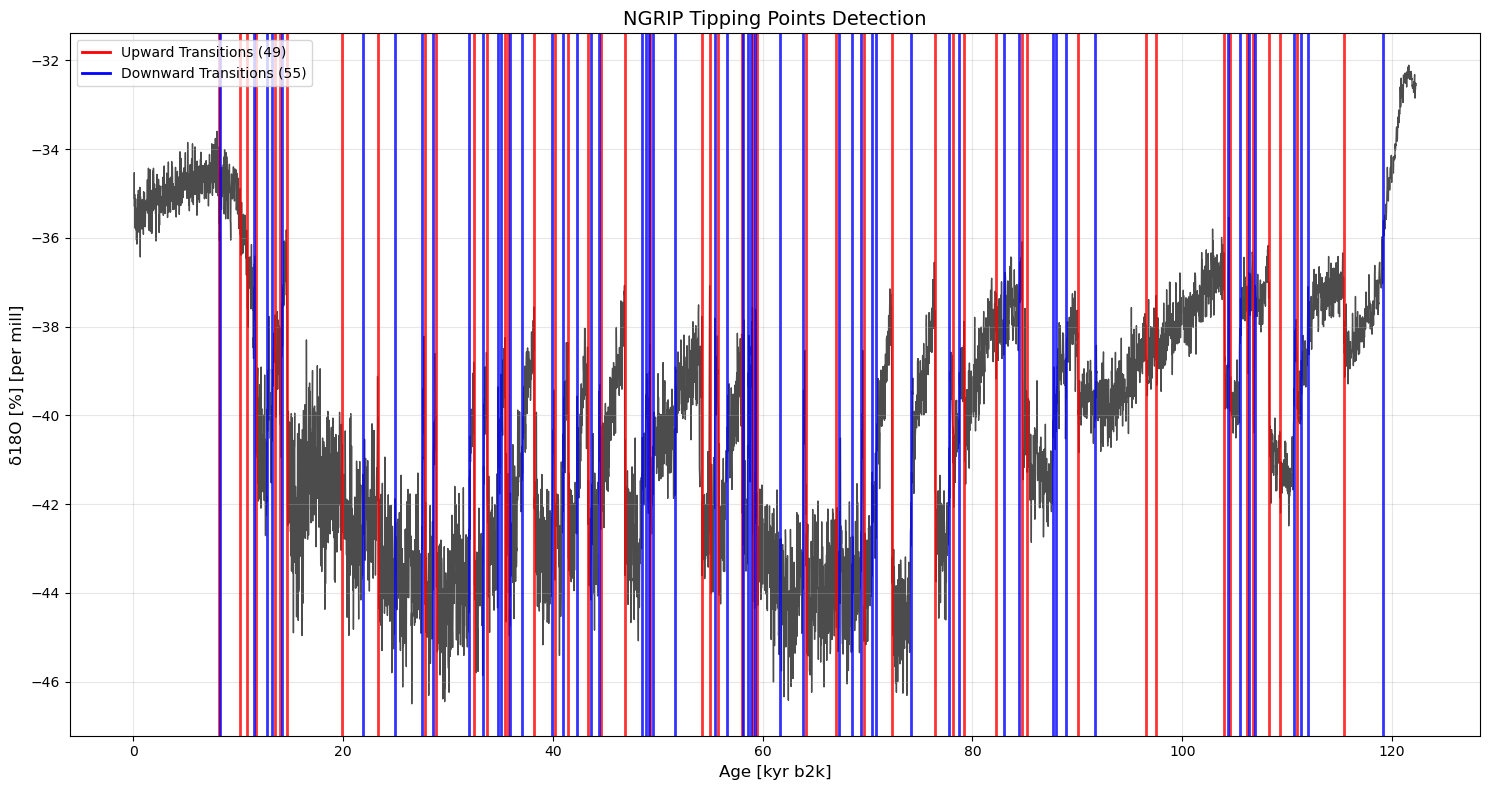

In [8]:
# Plot the results showing time series with detected transitions
fig, ax = transitions.plot(figsize=(15, 8), 
                          title='NGRIP Tipping Points Detection',
                          upward_color='red', 
                          downward_color='blue')
ax.grid(True, alpha=0.3)

## The results for the jumps

Deterministic Transition Detection Results - NGRIP Ice Core Data
+----------+---------------------+----------------+------------------+---------------------+
| Method   |   Total Transitions |   Upward Jumps |   Downward Jumps | Series Label        |
+==========+=====================+================+==================+=====================+
| KS test  |                 104 |             49 |               55 | NGRIP Ice Core Data |
+----------+---------------------+----------------+------------------+---------------------+

Transition Details:
  1. Time: 8.14 kyr b2k, Direction: Upward, d_statistics: 0.4080, p_values: < 1e-8
  2. Time: 8.30 kyr b2k, Direction: Downward, d_statistics: 0.3760, p_values: < 1e-7
  3. Time: 10.20 kyr b2k, Direction: Upward, d_statistics: 0.9203, p_values: < 1e-56
  4. Time: 10.86 kyr b2k, Direction: Upward, d_statistics: 0.9680, p_values: < 1e-65
  5. Time: 11.52 kyr b2k, Direction: Downward, d_statistics: 0.9040, p_values: < 1e-53
  6. Time: 11.68 kyr b2k

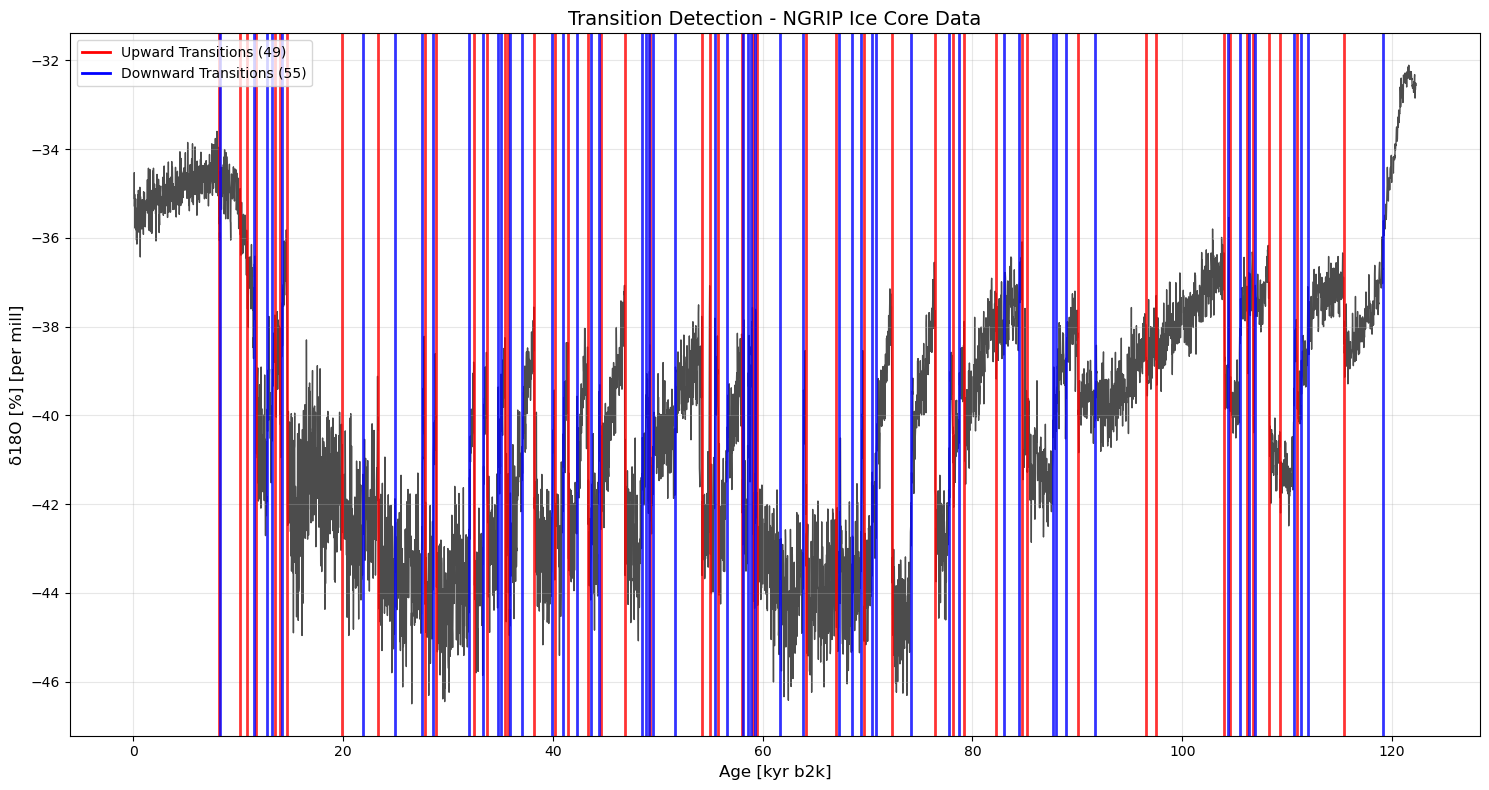

In [9]:
# Display comprehensive results summary
print(transitions)
fig, ax = transitions.plot(figsize=(15, 8))
print(f"Detected {len(transitions.jump_times)} transitions in NGRIP ice core record")